In [38]:
import numpy as np
import torch
import gymnasium as gym
from dataclasses import dataclass


class CustomMountainCar(gym.Wrapper): # custom wrapper to not use the internal reward
    def __init__(self, env, goal_reward=1.0, step_reward=0.0):
        super().__init__(env)
        self.goal_reward = goal_reward
        self.step_reward = step_reward

    def step(self, action):
        obs, _, terminated, truncated, info = self.env.step(action)
        position, velocity = obs
        goal_position = self.unwrapped.goal_position
        reward = self.goal_reward if position >= goal_position else self.step_reward
        return obs, reward, terminated, truncated, info


@dataclass # typed container for batches of replay data
class ReplayBatch:
    obs: torch.Tensor
    actions: torch.Tensor
    rewards: torch.Tensor
    next_obs: torch.Tensor
    terminated: torch.Tensor
    truncated: torch.Tensor
    episode_id: torch.Tensor
    timestep: torch.Tensor
    indices: torch.Tensor

    def _len_(self):
        return self.obs.shape[0]


class TrajectoryReplayBuffer:
    def __init__(self, capacity, obs_dim, action_dim, device="cpu"):
        self.capacity = capacity
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.device = device

        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, action_dim), dtype=np.float32)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.terminated = np.zeros((capacity, 1), dtype=np.float32)
        self.truncated = np.zeros((capacity, 1), dtype=np.float32)

        self.episode_id = np.full((capacity,), -1, dtype=np.int64)
        self.timestep = np.full((capacity,), -1, dtype=np.int64)

        self.pos = 0
        self.size = 0
        self.full = False

        self.current_episode_id = 0
        self.episode_to_indices = {}

    def __len__(self):
        return self.size

    def add_episode(self, episode):
        ep_id = self.current_episode_id
        self.current_episode_id += 1

        ep_indices = []

        T = len(episode["obs"])
        for t in range(T):
            idx = self.pos

            if self.full:
                old_ep = self.episode_id[idx]
                if old_ep in self.episode_to_indices:
                    try:
                        self.episode_to_indices[old_ep].remove(idx)
                        if len(self.episode_to_indices[old_ep]) == 0:
                            del self.episode_to_indices[old_ep]
                    except ValueError:
                        pass

            self.obs[idx] = np.asarray(episode["obs"][t], dtype=np.float32)
            self.actions[idx] = np.asarray(episode["actions"][t], dtype=np.float32).reshape(-1)
            self.rewards[idx] = np.asarray([episode["rewards"][t]], dtype=np.float32)
            self.next_obs[idx] = np.asarray(episode["next_obs"][t], dtype=np.float32)
            self.terminated[idx] = np.asarray([episode["terminated"][t]], dtype=np.float32)
            self.truncated[idx] = np.asarray([episode["truncated"][t]], dtype=np.float32)

            self.episode_id[idx] = ep_id
            self.timestep[idx] = t

            ep_indices.append(idx)

            self.pos = (self.pos + 1) % self.capacity
            if self.size < self.capacity:
                self.size += 1
            else:
                self.full = True

        self.episode_to_indices[ep_id] = ep_indices

    def sample(self, batch_size):
        assert self.size > 0, "Buffer is empty"
        idxs = np.random.randint(0, self.size, size=batch_size)

        return ReplayBatch(
            obs=torch.tensor(self.obs[idxs], device=self.device),
            actions=torch.tensor(self.actions[idxs], device=self.device),
            rewards=torch.tensor(self.rewards[idxs], device=self.device),
            next_obs=torch.tensor(self.next_obs[idxs], device=self.device),
            terminated=torch.tensor(self.terminated[idxs], device=self.device),
            truncated=torch.tensor(self.truncated[idxs], device=self.device),
            episode_id=torch.tensor(self.episode_id[idxs], device=self.device),
            timestep=torch.tensor(self.timestep[idxs], device=self.device),
            indices=torch.tensor(idxs, device=self.device),
        )

    def sample_future_goal_batch(self, batch_size, min_k=1, max_k=None, gamma=0.99): # gamma controls the geometric distribution for positive-goal sampling
        assert self.size > 0, "Buffer is empty"

        valid_indices = []
        future_goal_indices = []

        tries = 0
        max_tries = batch_size * 20

        while len(valid_indices) < batch_size and tries < max_tries:
            idx = np.random.randint(0, self.size)
            ep_id = self.episode_id[idx]
            t = self.timestep[idx]

            if ep_id == -1 or ep_id not in self.episode_to_indices:
                tries += 1
                continue

            ep_idxs = self.episode_to_indices[ep_id]
            ep_len = len(ep_idxs)

            if t >= ep_len - 1:
                tries += 1
                continue

            max_valid_k = ep_len - 1 - t
            if max_k is not None:
                max_valid_k = min(max_valid_k, max_k)

            if max_valid_k < min_k:
                tries += 1
                continue

            geom_k = int(np.random.geometric(p=1.0 - gamma))  # k ~ Geometric(1-γ), matches sample_positive_future_goal
            k = max(min_k, min(geom_k, max_valid_k))  # clamp to [min_k, max_valid_k]
            future_t = t + k
            future_idx = ep_idxs[future_t]

            valid_indices.append(idx)
            future_goal_indices.append(future_idx)
            tries += 1

        assert len(valid_indices) > 0, "Could not sample valid future-goal pairs"

        idxs = np.array(valid_indices, dtype=np.int64)
        g_idxs = np.array(future_goal_indices, dtype=np.int64)

        batch = {
            "obs": torch.tensor(self.obs[idxs], device=self.device),
            "actions": torch.tensor(self.actions[idxs], device=self.device),
            "next_obs": torch.tensor(self.next_obs[idxs], device=self.device),
            "goals": torch.tensor(self.obs[g_idxs], device=self.device),
            "rewards": torch.tensor(self.rewards[idxs], device=self.device),
            "terminated": torch.tensor(self.terminated[idxs], device=self.device),
            "truncated": torch.tensor(self.truncated[idxs], device=self.device),
            "episode_id": torch.tensor(self.episode_id[idxs], device=self.device),
            "timestep": torch.tensor(self.timestep[idxs], device=self.device),
            "future_timestep": torch.tensor(self.timestep[g_idxs], device=self.device),
            "indices": torch.tensor(idxs, device=self.device),
            "goal_indices": torch.tensor(g_idxs, device=self.device),
        }
        return batch

    def sample_negative_future_goals(self, batch_size):
        idxs = np.random.randint(0, self.size, size=batch_size) # pick random indices from the buffer and indexing the observations
        return torch.tensor(self.obs[idxs], device=self.device)
    
    def sample_positive_future_goal(self, episode_index, timestep, k, gamma = 0.99):

        if episode_index not in self.episode_to_indices:
            raise ValueError(f"Episode index {episode_index} not found in buffer")

        ep_idxs = self.episode_to_indices[episode_index]
        ep_len = len(ep_idxs)

        if timestep >= ep_len - 1:
            raise ValueError(f"Timestep {timestep} is out of bounds for episode of length {ep_len}")

        max_valid_k = ep_len - 1 - timestep
        if k > max_valid_k:
            raise ValueError(f"k={k} is too large for episode of length {ep_len} at timestep {timestep}")

        geometric = torch.distributions.Geometric(probs=torch.tensor(1-gamma)) # geometric distribution to sample k with probability proportional to gamma^k
        steps_ahead = int(geometric.sample().item()) + 1 # sample k, cast to int, and add 1 to ensure it's at least t+1
        steps_ahead = min(steps_ahead, max_valid_k) # clamp so we never index past the end of the episode
        print(f"Sampled k={steps_ahead} from geometric distribution with gamma={gamma}")
        future_t = timestep + steps_ahead
        future_idx = ep_idxs[future_t]
        print(self.obs[future_idx])
        return torch.tensor(self.obs[future_idx], device=self.device) # return the future state as the positive goal

    def stats(self):
        return {
            "size": self.size,
            "capacity": self.capacity,
            "num_episodes": len(self.episode_to_indices),
            "current_episode_id": self.current_episode_id,
        }

### 2. Cell to Generate Data and push to replay buffer

In [39]:
EPISODES = 100
MAX_HORIZON = 200
BUFFER_CAPACITY = 500000
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

env = gym.make(
    "MountainCarContinuous-v0",
    max_episode_steps=MAX_HORIZON,
)
env = CustomMountainCar(env)

obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

replay_buffer = TrajectoryReplayBuffer(
    capacity=BUFFER_CAPACITY,
    obs_dim=obs_dim,
    action_dim=action_dim,
    device=DEVICE,
)
print(DEVICE)
episodes = []

for epi in range(EPISODES):
    obs, _ = env.reset()
    done = False
    t = 0

    ep = {k: [] for k in ["obs", "actions", "rewards", "next_obs", "terminated", "truncated"]}

    while not done:
        action = env.action_space.sample().astype(np.float32)
        next_obs, reward, term, trunc, info = env.step(action)

        ep["obs"].append(obs.astype(np.float32))
        ep["actions"].append(action.astype(np.float32))
        ep["rewards"].append(np.float32(reward))
        ep["next_obs"].append(next_obs.astype(np.float32))
        ep["terminated"].append(np.float32(term))
        ep["truncated"].append(np.float32(trunc))

        obs = next_obs
        done = term or trunc
        t += 1

    ep_np = {k: np.asarray(v, dtype=np.float32) for k, v in ep.items()}
    episodes.append(ep_np)
    replay_buffer.add_episode(ep_np)

env.close()

print("Collected episodes:", len(episodes))
print("Replay stats:", replay_buffer.stats())

mps
Collected episodes: 100
Replay stats: {'size': 20000, 'capacity': 500000, 'num_episodes': 100, 'current_episode_id': 100}


### 3. To check the distribution sampling for Contrastive loss

In [40]:
batch = replay_buffer.sample(batch_size=256) # sampling state and actions randomly from the replay buffer
s = batch.obs
a = batch.actions

episode_idx = batch.episode_id # need this for actual future state sampling
timestep = batch.timestep # need this for actual future state sampling
s_pos_next = replay_buffer.sample_positive_future_goal(episode_idx[0].item(), timestep[0].item(), k=10) # sample a positive future goal index for the first sample in the batch, using k=10 for the geometric distribution
s_neg_next = replay_buffer.sample_negative_future_goals(batch_size=256) # sample negative future goals randomly from the buffer

positive_dot_product = torch.dot(s[0], s_pos_next)  # raw (unlearned) dot product, just to show data flow before representations are trained
print("positive dot product (raw):", positive_dot_product.item())

for s,a,s_next in zip(batch.obs, batch.actions, batch.next_obs):
    print("s:", s.cpu().numpy(), "a:", a.cpu().numpy(), "s_next:", s_next.cpu().numpy())

# the experience tuples are stored in the replay buffer as tensors, and to visualise it use cpu.numpy

Sampled k=100 from geometric distribution with gamma=0.99
[-0.47205782 -0.0069461 ]
positive dot product (raw): 0.20693127810955048
s: [-4.3835801e-01 -1.3696915e-04] a: [-0.27581912] s_next: [-0.43954107 -0.00118306]
s: [-0.56046945  0.00543751] a: [0.83526814] s_next: [-0.5535031   0.00696638]
s: [-0.6023933 -0.0019345] a: [-0.60307556] s_next: [-0.604647   -0.00225365]
s: [-0.58311886 -0.00718717] a: [-0.9362992] s_next: [-0.59126645 -0.00814759]
s: [-0.48554003 -0.00184446] a: [0.76772493] s_next: [-0.48651773 -0.00097769]
s: [-0.43430066 -0.00290661] a: [-0.9105821] s_next: [-0.4392349  -0.00493424]
s: [-0.49516705 -0.01114125] a: [-0.6185199] s_next: [-0.50744903 -0.01228201]
s: [-0.5868797  -0.00228213] a: [-0.25835425] s_next: [-0.5890776 -0.0021979]
s: [-0.42166424  0.00553796] a: [0.41316155] s_next: [-0.4162592   0.00540505]
s: [-0.7051388  -0.01673579] a: [-0.30521744] s_next: [-0.7210372  -0.01589838]
s: [-0.57859087 -0.0070388 ] a: [-0.73184013] s_next: [-0.5863169  -0.00

### 4. The implementation of A Single Goal is All you Need.

In [ ]:
# Now here is the NN to train the sampled batch data from the replay buffer, the goal is to learn a dynamics model that predicts s_next from (s,a) pairs.

import torch.nn as nn
import torch.optim as optim 
import torch.nn.functional as F

class StateActionRepresentationModel(nn.Module): # a simple MLP that takes in (s,a) and predicts s_next, use hidden_layers to control the depth of the MLP, and hidden_dim to control the width of the MLP

    def __init__(self, obs_dim, action_dim, hidden_dim=256, output_dim=64, hidden_layers=5,normalise=False): # A single goal paper specifies no normalisation
        super().__init__()
        self.fc1 = nn.Linear(obs_dim + action_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(hidden_layers - 2)])
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.normalise = normalise

    def forward(self, x):
        x = F.relu(self.fc1(x))
        for layer in self.hidden_layers:
            x = F.relu(layer(x))
        x = self.fc_out(x)
        if self.normalise: # if normalise is True, then we normalise the output to have unit norm, this can help with training stability and convergence, especially when using MSE loss, as it prevents the model from producing arbitrarily large outputs
            x = F.normalize(x, dim=-1)
        return x


In [ ]:
class GoalRepresentationModel(nn.Module): # symmetric counterpart to StateActionRepresentationModel — maps a future/goal state sf to an embedding ψ(sf)

    def __init__(self, obs_dim, hidden_dim=256, hidden_layers=5, output_dim=64, normalise=False): # same architecture choices as phi to keep the embedding space consistent
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(hidden_layers - 2)])
        self.fc_out = nn.Linear(hidden_dim, output_dim) # output in the same embedding space as StateActionRepresentationModel so that the dot product phi(s,a)^T psi(sf) is well-defined
        self.normalise = normalise

    def forward(self, x):
        x = F.relu(self.fc1(x))
        for layer in self.hidden_layers:
            x = F.relu(layer(x))
        x = self.fc_out(x)
        if self.normalise: # paper specifies no normalisation, but we keep the flag for experimentation
            x = F.normalize(x, dim=-1)
        return x


In [43]:
def contrastive_loss(phi_sa, psi_sf_pos, psi_sf_neg, reg_coef=0.01):
    # Implements the contrastive RL objective from Eq. 3 of the paper:
    #   max  E[ log( e^{phi(s,a)^T psi(sf+)} / (e^{phi(s,a)^T psi(sf+)} + sum_j e^{phi(s,a)^T psi(sf_j-)}) )
    #           - 0.01 * log( sum_j e^{phi(s,a)^T psi(sf_j)} )^2 ]   <- LogSumExp regularisation
    #
    # phi_sa     : (B, d)  state-action embeddings phi(s, a)
    # psi_sf_pos : (B, d)  positive future-state embeddings psi(sf+), sampled via Geometric(1-γ) k steps ahead
    # psi_sf_neg : (B, d)  negative future-state embeddings psi(sf-), sampled uniformly from the replay buffer (marginal distribution)
    #
    # For each anchor phi_sa[i]:
    #   - one positive  : phi_sa[i]^T psi_sf_pos[i]   (col 0 of all_logits)
    #   - B negatives   : phi_sa[i]^T psi_sf_neg[j] for all j  (cols 1..B)
    # This keeps positives and negatives cleanly separated (no accidental positive-as-negative contamination).

    B = phi_sa.shape[0]

    pos_logits = (phi_sa * psi_sf_pos).sum(dim=-1, keepdim=True)  # (B, 1)  one dot-product per positive pair
    neg_logits = phi_sa @ psi_sf_neg.T                            # (B, B)  phi(s_i,a_i)^T psi(sf_j-) for all j

    all_logits = torch.cat([pos_logits, neg_logits], dim=1)  # (B, 1+B): column 0 is the positive
    labels = torch.zeros(B, dtype=torch.long, device=phi_sa.device)  # label 0 = column 0 = positive

    infonce_loss = F.cross_entropy(all_logits, labels)  # minimising this maximises the infoNCE term

    logsumexp = torch.logsumexp(all_logits, dim=-1)  # (B,), log sum_j exp(logit_j)
    reg_loss  = reg_coef * logsumexp.pow(2).mean()   # penalise large LogSumExp values (matches -0.01 * (...) in the maximisation objective)

    return infonce_loss + reg_loss  # minimise this to maximise the paper's contrastive objective


In [44]:
LOG_STD_MIN = -5
LOG_STD_MAX =  2

class GoalConditionedActor(nn.Module): # goal-conditioned policy pi(a | s, g) — takes (s, g) and outputs a Gaussian action distribution

    def __init__(self, obs_dim, action_dim, hidden_dim=256, hidden_layers=5):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim * 2, hidden_dim)  # concatenate state s and goal g as input
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(hidden_layers - 2)])
        self.fc_mean    = nn.Linear(hidden_dim, action_dim)   # output the mean of the action distribution
        self.log_std_fc = nn.Linear(hidden_dim, action_dim)   # state-dependent log-std head

    def forward(self, obs, goal):
        x = torch.cat([obs, goal], dim=-1)  # (B, obs_dim * 2)
        x = F.relu(self.fc1(x))
        for layer in self.hidden_layers:
            x = F.relu(layer(x))
        mean    = self.fc_mean(x)  # (B, action_dim)
        log_std = self.log_std_fc(x).clamp(LOG_STD_MIN, LOG_STD_MAX)  # (B, action_dim)
        return mean, log_std

    def sample_action(self, obs, goal):
        mean, log_std = self.forward(obs, goal)
        std  = log_std.exp()
        dist = torch.distributions.Normal(mean, std)

        # Reparameterised sample
        x_t    = dist.rsample()

        # Squash through tanh so actions always lie in (-1, 1)
        action = torch.tanh(x_t)

        # Correct log-prob for the tanh change-of-variables:
        # log π(a|s,g) = log N(x_t; μ, σ) - Σ log(1 - tanh²(x_t))
        log_prob = (dist.log_prob(x_t) - torch.log(1 - action.pow(2) + 1e-6)).sum(dim=-1, keepdim=True)  # (B, 1)
        entropy  = dist.entropy().sum(dim=-1, keepdim=True)  # (B, 1), H(pi(.|s,g))
        return action, log_prob, entropy


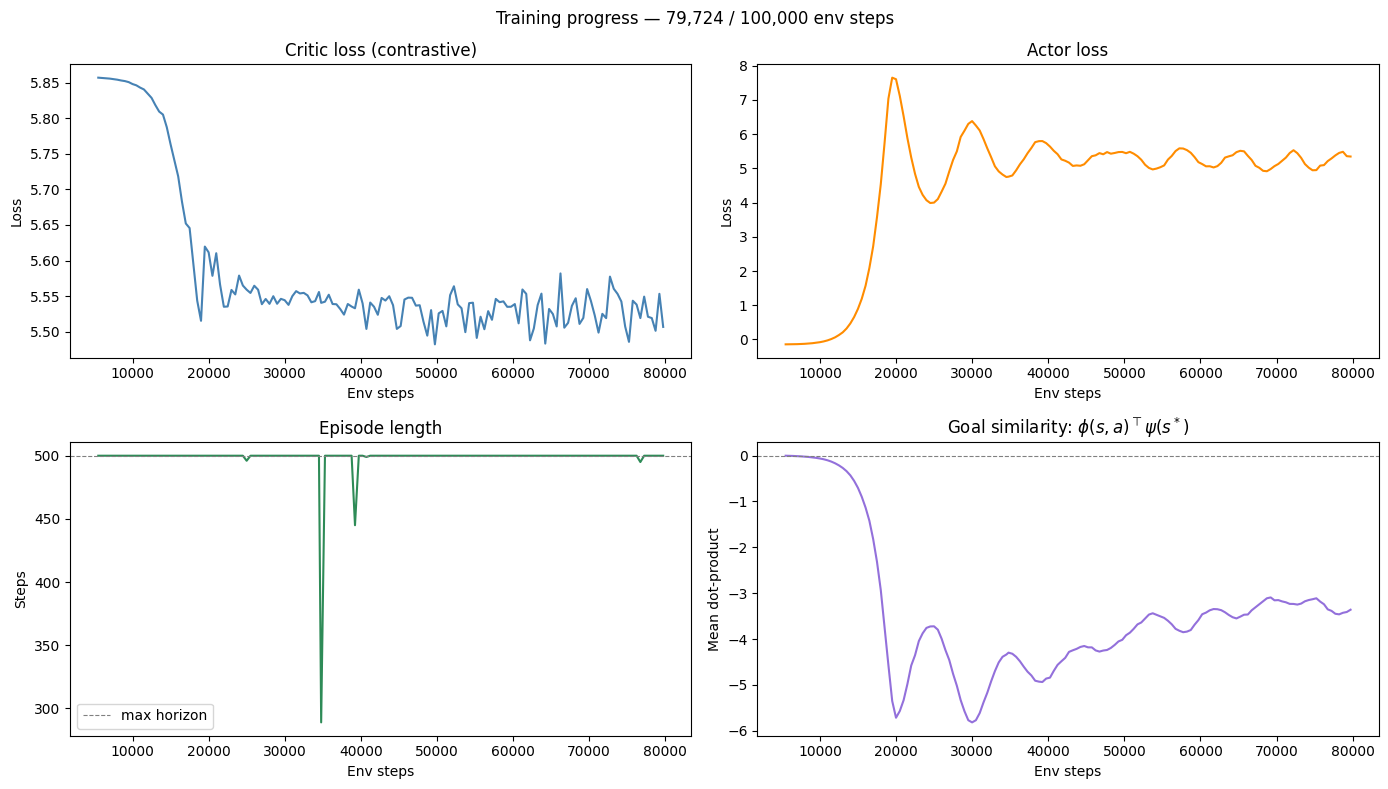

Training complete!
Total env steps: 100,037 | Gradient updates: 191
Replay buffer size: 100,037


In [ ]:
# ── Imports for live visualisation ────────────────────────────────────────────
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ── Hyperparameters ────────────────────────────────────────────────────────────
TOTAL_ENV_STEPS = 100000  # total environment steps to collect (priority-1 fix: was 200 episodes ≈ 100k max, now explicit lower bound)
WARMUP_STEPS    = 10000    # random-action steps before any gradient updates (priority-2 fix: ensures diverse negatives in buffer)
BATCH_SIZE      = 256      # samples per gradient update
LR              = 3e-4    # learning rate for all networks
ALPHA           = 0.1     # entropy coefficient for the actor loss (Eq. 4)
LOG_INTERVAL    = 50       # refresh the live plot every this many gradient-update steps
MAX_HORIZON     = 500
BUFFER_CAPACITY = 500000
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

# ── Single hard goal s* (Alg. 1, line 3) ──────────────────────────────────────
# For MountainCarContinuous the goal is to reach position >= 0.45 with any velocity.
# s* = [0.45, 0.0] is a valid env observation (position=goal_position, velocity=0).
s_star = torch.tensor([0.45, 0.0], device=DEVICE, dtype=torch.float32)

# ── Environment ───────────────────────────────────────────────────────────────
env_train = gym.make("MountainCarContinuous-v0", max_episode_steps=MAX_HORIZON)
env_train = CustomMountainCar(env_train)

obs_dim    = env_train.observation_space.shape[0]
action_dim = env_train.action_space.shape[0]

replay_buffer = TrajectoryReplayBuffer(
    capacity=BUFFER_CAPACITY,
    obs_dim=obs_dim,
    action_dim=action_dim,
    device=DEVICE,
)
print(DEVICE)

phi_model = StateActionRepresentationModel(obs_dim, action_dim, hidden_dim=256, output_dim=64, hidden_layers=5).to(DEVICE)
psi_model = GoalRepresentationModel(obs_dim, hidden_dim=256, output_dim=64, hidden_layers=5).to(DEVICE)
actor     = GoalConditionedActor(obs_dim, action_dim, hidden_dim=256, hidden_layers=5).to(DEVICE)

critic_optimizer = optim.Adam(list(phi_model.parameters()) + list(psi_model.parameters()), lr=LR)
actor_optimizer  = optim.Adam(actor.parameters(), lr=LR)

# ── History buffers for visualisation ─────────────────────────────────────────
critic_loss_history   = []
actor_loss_history    = []
ep_len_history        = []
entropy_history       = []
env_steps_at_update   = []  # x-axis: total env steps when each gradient update was performed
goal_similarity_history = []  # mean phi(s,a)^T psi(s*) over each batch — diagnostic for point 6

# ── Helper: collect one episode into a dict ────────────────────────────────────
def collect_episode(env, policy_fn):
    """Run one episode. policy_fn(obs_tensor) -> action_np. Returns (ep_dict, ep_steps)."""
    obs_t, _ = env.reset()
    done = False
    ep = {k: [] for k in ["obs", "actions", "rewards", "next_obs", "terminated", "truncated"]}
    while not done:
        action_np = policy_fn(obs_t)
        next_obs_t, reward, term, trunc, _ = env.step(action_np)
        ep["obs"].append(obs_t.astype(np.float32))
        ep["actions"].append(action_np.astype(np.float32))
        ep["rewards"].append(np.float32(reward))
        ep["next_obs"].append(next_obs_t.astype(np.float32))
        ep["terminated"].append(np.float32(term))
        ep["truncated"].append(np.float32(trunc))
        obs_t = next_obs_t
        done  = term or trunc
    return ep, len(ep["obs"])

# ── Phase 1: Random-action warmup (Alg. priority-2 fix) ──────────────────────
# Collect WARMUP_STEPS transitions using purely random actions so that the
# replay buffer already contains diverse (s, a, sf) triples before the first
# gradient update.  This prevents early contrastive batches from being dominated
# by near-identical near-reset states, which would make the negatives too easy.
total_env_steps = 0
print(f"Warmup: collecting {WARMUP_STEPS:,} random-action steps …")

def random_policy(obs_t):
    return env_train.action_space.sample()

while total_env_steps < WARMUP_STEPS:
    ep, ep_steps = collect_episode(env_train, random_policy)
    replay_buffer.add_episode(ep)
    total_env_steps += ep_steps

print(f"Warmup done.  Buffer size: {replay_buffer.size:,} transitions  "
      f"({total_env_steps:,} env steps collected).")

# ── Phase 2: Main training loop (Alg. 1, lines 2-4) ──────────────────────────
# Run until we have collected TOTAL_ENV_STEPS total environment interactions
# (warmup steps + policy steps).  Each outer iteration: collect one on-policy
# trajectory with the current actor, then do one critic + one actor gradient step.
grad_step = 0   # counts gradient update iterations (for logging and x-axis)
print(f"Training: will run until {TOTAL_ENV_STEPS:,} total env steps …")

s_star_batch = s_star.unsqueeze(0)  # (1, obs_dim)

while total_env_steps < TOTAL_ENV_STEPS:

    # ── Collect one trajectory using pi(a | s, g = s*) (Alg. 1, line 3) ────
    def actor_policy(obs_t):
        obs_tensor = torch.tensor(obs_t, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            action, _, _ = actor.sample_action(obs_tensor, s_star_batch)
        action_np = action.squeeze(0).cpu().numpy()
        return action_np

    ep, ep_steps = collect_episode(env_train, actor_policy)
    replay_buffer.add_episode(ep)
    total_env_steps += ep_steps
    grad_step       += 1

    # ── Critic update (Eq. 3) ─────────────────────────────────────────────
    batch = replay_buffer.sample_future_goal_batch(BATCH_SIZE)

    obs     = batch["obs"]
    actions = batch["actions"]
    goals   = batch["goals"]

    phi_sa    = phi_model(torch.cat([obs, actions], dim=-1))
    psi_g     = psi_model(goals)
    neg_goals = replay_buffer.sample_negative_future_goals(BATCH_SIZE)
    psi_neg   = psi_model(neg_goals)

    critic_loss = contrastive_loss(phi_sa, psi_g, psi_neg)

    critic_optimizer.zero_grad()
    critic_loss.backward()
    critic_optimizer.step()

    # ── Goal-similarity diagnostic: mean phi(s,a)^T psi(s*) (point 6) ───
    # Measures whether the current-state–action embedding is growing more
    # similar to the fixed goal embedding over time.  A rising curve means
    # the representation is "pointing toward" s*.
    with torch.no_grad():
        psi_sstar = psi_model(s_star.unsqueeze(0).expand(BATCH_SIZE, -1))  # (B, d)
        goal_sim  = (phi_sa.detach() * psi_sstar).sum(dim=-1).mean().item()
    goal_similarity_history.append(goal_sim)

    # ── Actor update (Eq. 4) ──────────────────────────────────────────────
    sampled_actions, _, entropy = actor.sample_action(obs, goals)

    phi_sa_actor = phi_model(torch.cat([obs, sampled_actions], dim=-1))
    psi_g_actor  = psi_model(goals)

    # ψ(g) is detached so the actor loss does not update the goal encoder —
    # gradients flow only through φ(s, a_sampled), i.e. through the actor.
    q_values   = (phi_sa_actor * psi_g_actor.detach()).sum(dim=-1, keepdim=True)
    actor_loss = -(q_values + ALPHA * entropy).mean()

    actor_optimizer.zero_grad()
    actor_loss.backward()
    actor_optimizer.step()

    # ── Record metrics ────────────────────────────────────────────────────
    critic_loss_history.append(critic_loss.item())
    actor_loss_history.append(actor_loss.item())
    ep_len_history.append(ep_steps)
    entropy_history.append(entropy.detach().mean().item())
    env_steps_at_update.append(total_env_steps)

    # ── Live plot every LOG_INTERVAL gradient steps ───────────────────────
    if grad_step % LOG_INTERVAL == 0:
        print(f"GradStep {grad_step:>5} | env_steps: {total_env_steps:>7,} | ep_len: {ep_steps:>3} | "
              f"critic_loss: {critic_loss.item():.4f} | actor_loss: {actor_loss.item():.4f} | "
              f"goal_sim: {goal_sim:.4f}")

        clear_output(wait=True)
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        axes = axes.flatten()

        axes[0].plot(env_steps_at_update, critic_loss_history, color='steelblue')
        axes[0].set_title("Critic loss (contrastive)")
        axes[0].set_xlabel("Env steps")
        axes[0].set_ylabel("Loss")

        axes[1].plot(env_steps_at_update, actor_loss_history, color='darkorange')
        axes[1].set_title("Actor loss")
        axes[1].set_xlabel("Env steps")
        axes[1].set_ylabel("Loss")

        axes[2].plot(env_steps_at_update, ep_len_history, color='seagreen')
        axes[2].axhline(MAX_HORIZON, color='gray', linestyle='--', linewidth=0.8, label='max horizon')
        axes[2].set_title("Episode length")
        axes[2].set_xlabel("Env steps")
        axes[2].set_ylabel("Steps")
        axes[2].legend()

        axes[3].plot(env_steps_at_update, goal_similarity_history, color='mediumpurple')
        axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        axes[3].set_title(r"Goal similarity: $\phi(s,a)^\top\psi(s^*)$")
        axes[3].set_xlabel("Env steps")
        axes[3].set_ylabel("Mean dot-product")

        plt.suptitle(f"Training progress — {total_env_steps:,} / {TOTAL_ENV_STEPS:,} env steps", fontsize=12)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

env_train.close()
print("Training complete!")
print(f"Total env steps: {total_env_steps:,} | Gradient updates: {grad_step:,}")
print(f"Replay buffer size: {replay_buffer.stats()['size']:,}")


### 5. Post-training summary plots


### 5a. Diagnostic: Network I/O distributions & positive/negative batch example

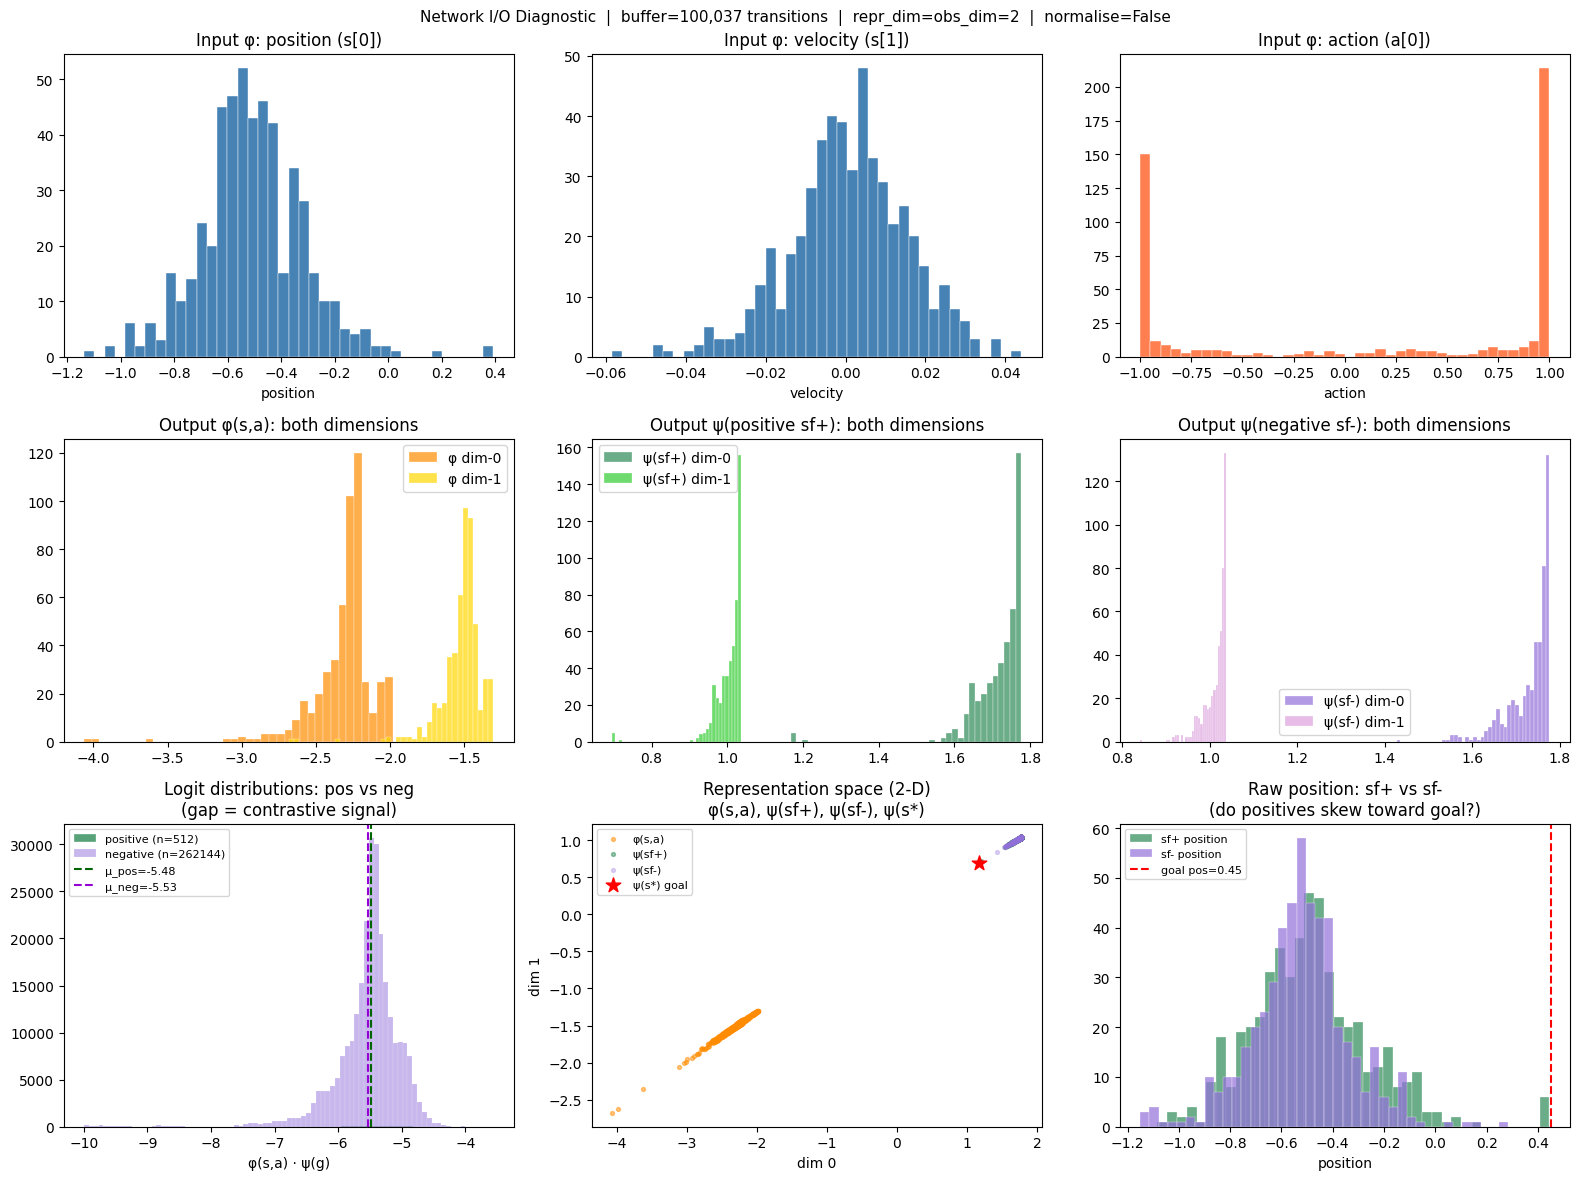


Summary statistics:
  φ(s,a) output  — mean: -1.911  std: 0.436  min: -4.064  max: -1.302
  ψ(sf+)  output  — mean: 1.361  std: 0.362  min: 0.696  max: 1.777
  ψ(sf-)  output  — mean: 1.373  std: 0.362  min: 0.841  max: 1.777
  pos logits      — mean: -5.477  std: 0.469
  neg logits      — mean: -5.531  std: 0.535
  contrastive gap (μ_pos - μ_neg): 0.054  (positive = good)


In [46]:
# ── Diagnostic: visualise network inputs, outputs, and one contrastive batch ──────
# Run this cell after training (phi_model, psi_model, replay_buffer must exist).
#
# Panel layout:
#   Row 1: distributions of raw network inputs  (state, action, goal)
#   Row 2: distributions of network outputs φ(s,a) and ψ(g)
#   Row 3: concrete single-batch example — pos logit vs neg logits distribution
#          + scatter of φ and ψ in 2-D representation space

import matplotlib.pyplot as plt
import numpy as np
import torch

_DIAG_B = 512   # batch size used for diagnostics
phi_model.eval()
psi_model.eval()

with torch.no_grad():
    # ── Sample a batch with positive future goals ─────────────────────────
    dbatch   = replay_buffer.sample_future_goal_batch(_DIAG_B)
    d_obs    = dbatch["obs"]      # (B, 2)  [position, velocity]
    d_act    = dbatch["actions"]  # (B, 1)  action
    d_goals  = dbatch["goals"]    # (B, 2)  positive future state sf+
    d_neg    = replay_buffer.sample_negative_future_goals(_DIAG_B)  # (B, 2) negatives

    # ── Network outputs ───────────────────────────────────────────────────
    d_phi    = phi_model(torch.cat([d_obs, d_act], dim=-1))  # (B, 2)
    d_psi_p  = psi_model(d_goals)    # (B, 2)  positive goal repr
    d_psi_n  = psi_model(d_neg)      # (B, 2)  negative goal repr

    # ── Logit distributions ───────────────────────────────────────────────
    pos_logits = (d_phi * d_psi_p).sum(dim=-1).cpu().numpy()      # (B,) diagonal
    neg_logits = (d_phi @ d_psi_n.T).cpu().numpy().flatten()      # (B*B,) all cross

    d_obs_np   = d_obs.cpu().numpy()
    d_act_np   = d_act.cpu().numpy()
    d_goals_np = d_goals.cpu().numpy()
    d_neg_np   = d_neg.cpu().numpy()
    d_phi_np   = d_phi.cpu().numpy()
    d_psi_p_np = d_psi_p.cpu().numpy()
    d_psi_n_np = d_psi_n.cpu().numpy()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# ── Row 0: input distributions ────────────────────────────────────────────────
axes[0, 0].hist(d_obs_np[:, 0], bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0, 0].set_title('Input φ: position (s[0])')
axes[0, 0].set_xlabel('position')

axes[0, 1].hist(d_obs_np[:, 1], bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0, 1].set_title('Input φ: velocity (s[1])')
axes[0, 1].set_xlabel('velocity')

axes[0, 2].hist(d_act_np[:, 0], bins=40, color='coral', edgecolor='white', linewidth=0.3)
axes[0, 2].set_title('Input φ: action (a[0])')
axes[0, 2].set_xlabel('action')

# ── Row 1: network output distributions ───────────────────────────────────────
axes[1, 0].hist(d_phi_np[:, 0], bins=40, color='darkorange', edgecolor='white', linewidth=0.3, label='φ dim-0', alpha=0.7)
axes[1, 0].hist(d_phi_np[:, 1], bins=40, color='gold',       edgecolor='white', linewidth=0.3, label='φ dim-1', alpha=0.7)
axes[1, 0].set_title('Output φ(s,a): both dimensions')
axes[1, 0].legend()

axes[1, 1].hist(d_psi_p_np[:, 0], bins=40, color='seagreen',    edgecolor='white', linewidth=0.3, label='ψ(sf+) dim-0', alpha=0.7)
axes[1, 1].hist(d_psi_p_np[:, 1], bins=40, color='limegreen',   edgecolor='white', linewidth=0.3, label='ψ(sf+) dim-1', alpha=0.7)
axes[1, 1].set_title('Output ψ(positive sf+): both dimensions')
axes[1, 1].legend()

axes[1, 2].hist(d_psi_n_np[:, 0], bins=40, color='mediumpurple', edgecolor='white', linewidth=0.3, label='ψ(sf-) dim-0', alpha=0.7)
axes[1, 2].hist(d_psi_n_np[:, 1], bins=40, color='plum',         edgecolor='white', linewidth=0.3, label='ψ(sf-) dim-1', alpha=0.7)
axes[1, 2].set_title('Output ψ(negative sf-): both dimensions')
axes[1, 2].legend()

# ── Row 2: logit distributions + 2-D scatter ──────────────────────────────────
axes[2, 0].hist(pos_logits, bins=40, color='seagreen',    edgecolor='white', linewidth=0.3, label=f'positive (n={len(pos_logits)})', alpha=0.8)
axes[2, 0].hist(neg_logits, bins=80, color='mediumpurple', edgecolor='white', linewidth=0.2, label=f'negative (n={len(neg_logits)})', alpha=0.5)
axes[2, 0].axvline(np.mean(pos_logits), color='darkgreen',  linestyle='--', linewidth=1.5, label=f'μ_pos={np.mean(pos_logits):.2f}')
axes[2, 0].axvline(np.mean(neg_logits), color='darkviolet', linestyle='--', linewidth=1.5, label=f'μ_neg={np.mean(neg_logits):.2f}')
axes[2, 0].set_title('Logit distributions: pos vs neg\n(gap = contrastive signal)')
axes[2, 0].set_xlabel('φ(s,a) · ψ(g)')
axes[2, 0].legend(fontsize=8)

# 2-D scatter of φ and ψ in representation space
sc_phi = axes[2, 1].scatter(d_phi_np[:, 0],   d_phi_np[:, 1],   c='darkorange',    s=8, alpha=0.5, label='φ(s,a)')
sc_psp = axes[2, 1].scatter(d_psi_p_np[:, 0], d_psi_p_np[:, 1], c='seagreen',      s=8, alpha=0.5, label='ψ(sf+)')
sc_psn = axes[2, 1].scatter(d_psi_n_np[:, 0], d_psi_n_np[:, 1], c='mediumpurple',  s=8, alpha=0.3, label='ψ(sf-)')
# Mark s* goal
with torch.no_grad():
    psi_star_np = psi_model(s_star.unsqueeze(0)).cpu().numpy()
axes[2, 1].scatter(psi_star_np[0, 0], psi_star_np[0, 1], c='red', s=120, marker='*', zorder=5, label='ψ(s*) goal')
axes[2, 1].set_title('Representation space (2-D)\nφ(s,a), ψ(sf+), ψ(sf-), ψ(s*)')
axes[2, 1].set_xlabel('dim 0')
axes[2, 1].set_ylabel('dim 1')
axes[2, 1].legend(fontsize=8)

# Positive goal (sf+) input distribution vs negative goal (sf-) input distribution
axes[2, 2].hist(d_goals_np[:, 0], bins=40, color='seagreen',    edgecolor='white', linewidth=0.3, label='sf+ position', alpha=0.7)
axes[2, 2].hist(d_neg_np[:, 0],   bins=40, color='mediumpurple', edgecolor='white', linewidth=0.3, label='sf- position', alpha=0.7)
axes[2, 2].axvline(0.45, color='red', linestyle='--', linewidth=1.5, label='goal pos=0.45')
axes[2, 2].set_title('Raw position: sf+ vs sf-\n(do positives skew toward goal?)')
axes[2, 2].set_xlabel('position')
axes[2, 2].legend(fontsize=8)

plt.suptitle(
    f'Network I/O Diagnostic  |  buffer={replay_buffer.size:,} transitions  |  '
    f'repr_dim=obs_dim={obs_dim}  |  normalise={phi_model.normalise}',
    fontsize=11
)
plt.tight_layout()
plt.savefig('/tmp/network_io_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

phi_model.train()
psi_model.train()

print(f'\nSummary statistics:')
print(f'  φ(s,a) output  — mean: {d_phi_np.mean():.3f}  std: {d_phi_np.std():.3f}  min: {d_phi_np.min():.3f}  max: {d_phi_np.max():.3f}')
print(f'  ψ(sf+)  output  — mean: {d_psi_p_np.mean():.3f}  std: {d_psi_p_np.std():.3f}  min: {d_psi_p_np.min():.3f}  max: {d_psi_p_np.max():.3f}')
print(f'  ψ(sf-)  output  — mean: {d_psi_n_np.mean():.3f}  std: {d_psi_n_np.std():.3f}  min: {d_psi_n_np.min():.3f}  max: {d_psi_n_np.max():.3f}')
print(f'  pos logits      — mean: {pos_logits.mean():.3f}  std: {pos_logits.std():.3f}')
print(f'  neg logits      — mean: {neg_logits.mean():.3f}  std: {neg_logits.std():.3f}')
print(f'  contrastive gap (μ_pos - μ_neg): {pos_logits.mean() - neg_logits.mean():.3f}  (positive = good)')


ValueError: x and y must have same first dimension, but have shapes (200,) and (191,)

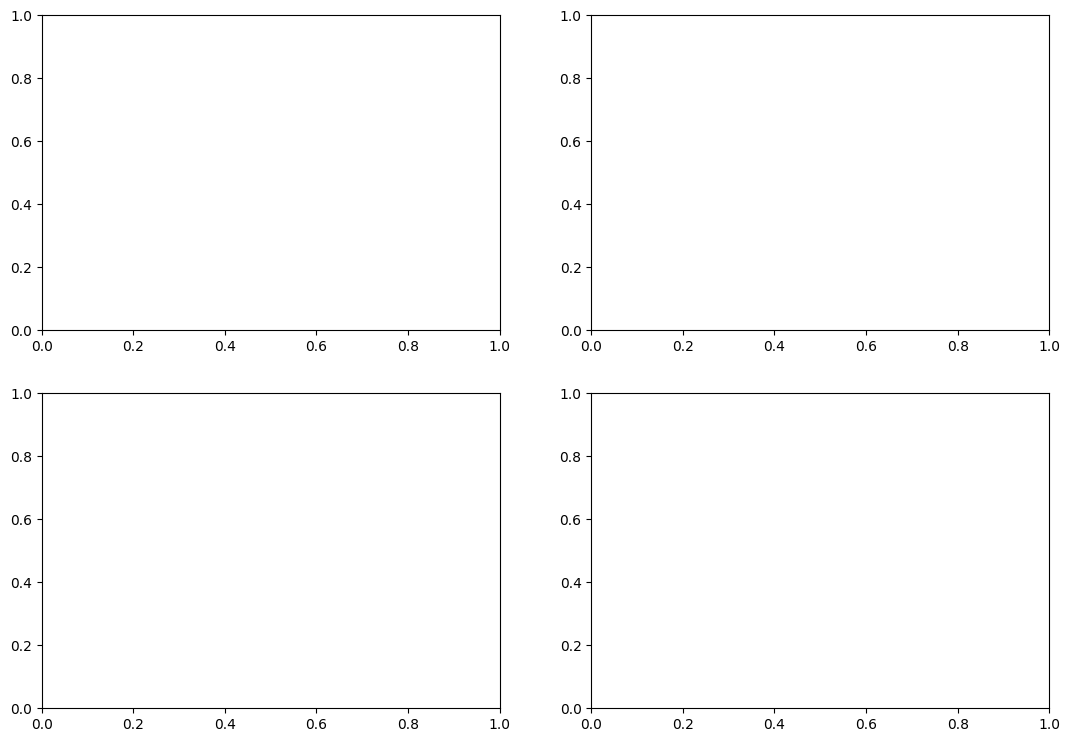

In [47]:
# ── Post-training summary: four-panel static plot ─────────────────────────────
# Smooth a 1-D list with a simple rolling window mean to reduce noise in the curves.
def smooth(values, window=10):
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode='valid')

steps_full = np.arange(1, TOTAL_ENV_STEPS//MAX_HORIZON + 1)
smooth_w   = max(1, TOTAL_ENV_STEPS // (20 * MAX_HORIZON))       # adaptive window: ~5 % of total steps

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ─ Critic loss ─
ax = axes[0, 0]
ax.plot(steps_full, critic_loss_history, color='steelblue', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(critic_loss_history, smooth_w),
        color='steelblue', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.set_title("Critic loss (contrastive, Eq. 3)")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.legend()

# ─ Actor loss ─
ax = axes[0, 1]
ax.plot(steps_full, actor_loss_history, color='darkorange', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(actor_loss_history, smooth_w),
        color='darkorange', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.set_title("Actor loss (Eq. 4)")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.legend()

# ─ Episode length ─
ax = axes[1, 0]
ax.plot(steps_full, ep_len_history, color='seagreen', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(ep_len_history, smooth_w),
        color='seagreen', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.axhline(MAX_HORIZON, color='gray', linestyle='--', linewidth=0.8, label=f'max horizon ({MAX_HORIZON})')
ax.set_title("Episode length")
ax.set_xlabel("Training step")
ax.set_ylabel("Steps per episode")
ax.legend()
# A shorter episode that terminates (rather than truncates) means the agent reached the goal.

# ─ Policy entropy ─
ax = axes[1, 1]
ax.plot(steps_full, entropy_history, color='mediumpurple', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(entropy_history, smooth_w),
        color='mediumpurple', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.set_title("Policy entropy  H(π(·|s, g))")
ax.set_xlabel("Training step")
ax.set_ylabel("Entropy (nats)")
ax.legend()
# Entropy should remain positive — if it collapses to zero the policy has become deterministic,
# which may indicate the temperature α is too low or the actor has overfit.

plt.suptitle("Post-training summary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 6. State-coverage heatmap


In [ ]:
# ── State-coverage heatmap ─────────────────────────────────────────────────────
# Visualise WHERE in (position, velocity) space the agent has been during training.
# Dense regions → well explored; sparse regions → rarely visited.
# If the goal position (0.45) is never reached, the right-hand side will be empty.

all_states = replay_buffer.obs[: replay_buffer.size]   # (N, 2) numpy array

positions  = all_states[:, 0]   # x-axis: car position ∈ [-1.2, 0.6]
velocities = all_states[:, 1]   # y-axis: car velocity ∈ [-0.07, 0.07]

fig, ax = plt.subplots(figsize=(9, 5))

h = ax.hist2d(
    positions, velocities,
    bins=[80, 60],
    range=[[-1.2, 0.6], [-0.07, 0.07]],
    cmap='YlOrRd',
    density=False,
)
cbar = plt.colorbar(h[3], ax=ax)
cbar.set_label("Visit count")

# Goal position marker
ax.axvline(0.45, color='lime', linewidth=1.5, linestyle='--', label='goal position (0.45)')

# Starting region: env resets position uniformly in [-0.6, -0.4]
ax.axvspan(-0.6, -0.4, alpha=0.12, color='dodgerblue', label='reset region')

ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.set_title("State-coverage heatmap (all replay-buffer transitions)")
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()
print(f"Plotted {replay_buffer.size:,} transitions.")


### 7. Final policy rollout — render learned behaviour


In [ ]:
# ── Render the learned policy and save as an animated GIF ─────────────────────
# The policy is always commanded toward the single hard goal s* = [0.45, 0.0].
# We run RENDER_EPISODES episodes, capture rgb_array frames, and produce a GIF
# so it can be viewed in the notebook and shared without a live display.

import imageio.v2 as imageio   # imageio ships with gymnasium as a dependency

RENDER_EPISODES = 3            # how many full rollouts to stitch together
RENDER_FPS      = 30           # frames per second in the output GIF

env_render = gym.make("MountainCarContinuous-v0",
                      render_mode="rgb_array",
                      max_episode_steps=MAX_HORIZON)
env_render = CustomMountainCar(env_render)

phi_model.eval()
psi_model.eval()
actor.eval()

all_frames   = []
ep_rewards   = []
ep_positions = []   # track position over time to visualise progress

s_star_render = s_star.unsqueeze(0)   # (1, obs_dim)

for ep_i in range(RENDER_EPISODES):
    obs_r, _ = env_render.reset()
    done_r    = False
    ep_rew    = 0.0
    positions_this_ep = []

    while not done_r:
        frame = env_render.render()    # (H, W, 3) uint8
        all_frames.append(frame)

        obs_tensor_r = torch.tensor(obs_r, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            action_r, _, _ = actor.sample_action(obs_tensor_r, s_star_render)
        action_r_np = action_r.squeeze(0).cpu().numpy()
        action_r_np = np.clip(action_r_np, env_render.action_space.low, env_render.action_space.high)

        obs_r, rew_r, term_r, trunc_r, _ = env_render.step(action_r_np)
        ep_rew += rew_r
        positions_this_ep.append(obs_r[0])
        done_r = term_r or trunc_r

    ep_rewards.append(ep_rew)
    ep_positions.append(positions_this_ep)
    print(f"  Rollout {ep_i+1}: {len(positions_this_ep)} steps | "
          f"total reward: {ep_rew:.2f} | "
          f"max position: {max(positions_this_ep):.3f}")

env_render.close()
phi_model.train()
psi_model.train()
actor.train()

gif_path = "/tmp/policy_rollout.gif"
imageio.mimsave(gif_path, all_frames, fps=RENDER_FPS, loop=0)
print(f"\nSaved GIF ({len(all_frames)} frames) → {gif_path}")

# Display the GIF inline (works in Jupyter Lab / Notebook)
from IPython.display import Image
Image(gif_path)


### 8. Per-rollout position trajectory plot


In [ ]:
# ── Position over time for each rendered rollout ──────────────────────────────
# Helps diagnose whether the agent builds up enough momentum to escape the valley.

fig, ax = plt.subplots(figsize=(10, 4))

colours = plt.cm.tab10.colors
for i, pos_traj in enumerate(ep_positions):
    ax.plot(pos_traj, color=colours[i % len(colours)],
            linewidth=1.5, label=f'Rollout {i+1}  (reward={ep_rewards[i]:.1f})')

ax.axhline(0.45,  color='lime',    linestyle='--', linewidth=1.2, label='goal (0.45)')
ax.axhline(-0.52, color='gray',    linestyle=':',  linewidth=0.8, label='valley bottom (≈−0.52)')
ax.set_xlabel("Timestep")
ax.set_ylabel("Car position")
ax.set_title("Learned policy — position over time (goal = 0.45)")
ax.legend(fontsize=9)
ax.set_ylim(-1.25, 0.65)

plt.tight_layout()
plt.show()
